# Análise de Biomassa por Plot

Cada linha é um plot de inventário. Sites usados como agrupamento visual.

**Três modelos (Longo et al. 2016):**
- **M1** — Chave 2014, todas as árvores, ρ médio (0.6 g/cm³)
- **M2** — equações separadas: vivas / mortas / palmeiras; ρ médio
- **M3** — igual M2 com ρ específico por espécie (GWDD Zanne/Chave 2009)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

ROOT    = Path("..")
SUMMARY = ROOT / "data/processed/05_biomass/summary.csv"

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

C_M1, C_M2, C_M3 = "#4a90d9", "#f5a623", "#e84545"

df = pd.read_csv(SUMMARY)
df["site_short"] = df["site"].str.replace(r"_inventory_plots|_inventory", "", regex=True)

# Plots com área válida para cálculo de densidade
dv = df[df["area_ha"].notna() & (df["area_ha"] > 0)].copy()
dv["arvores_ha"] = (dv["n_arvores"] / dv["area_ha"]).round(1)

print(f"Total: {len(df)} plots · {df.site.nunique()} sites")
print(f"Com área: {len(dv)} plots")
print(f"Árvores: {df.n_arvores.sum():,} (vivas {df.n_arvores_vivas.sum():,} · mortas {df.n_mortas.sum():,} · palmeiras {df.n_palmeiras.sum():,})")

Total: 150 plots · 21 sites
Com área: 146 plots
Árvores: 20,597 (vivas 15,102 · mortas 4,582 · palmeiras 737)


In [2]:
# Paleta de cores por site
sites = sorted(df["site_short"].unique())
cmap  = cm.get_cmap("tab20", len(sites))
site_color = {s: cmap(i) for i, s in enumerate(sites)}

/tmp/ipykernel_147349/752442374.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = cm.get_cmap("tab20", len(sites))


---
## 1. Distribuição de árvores por plot

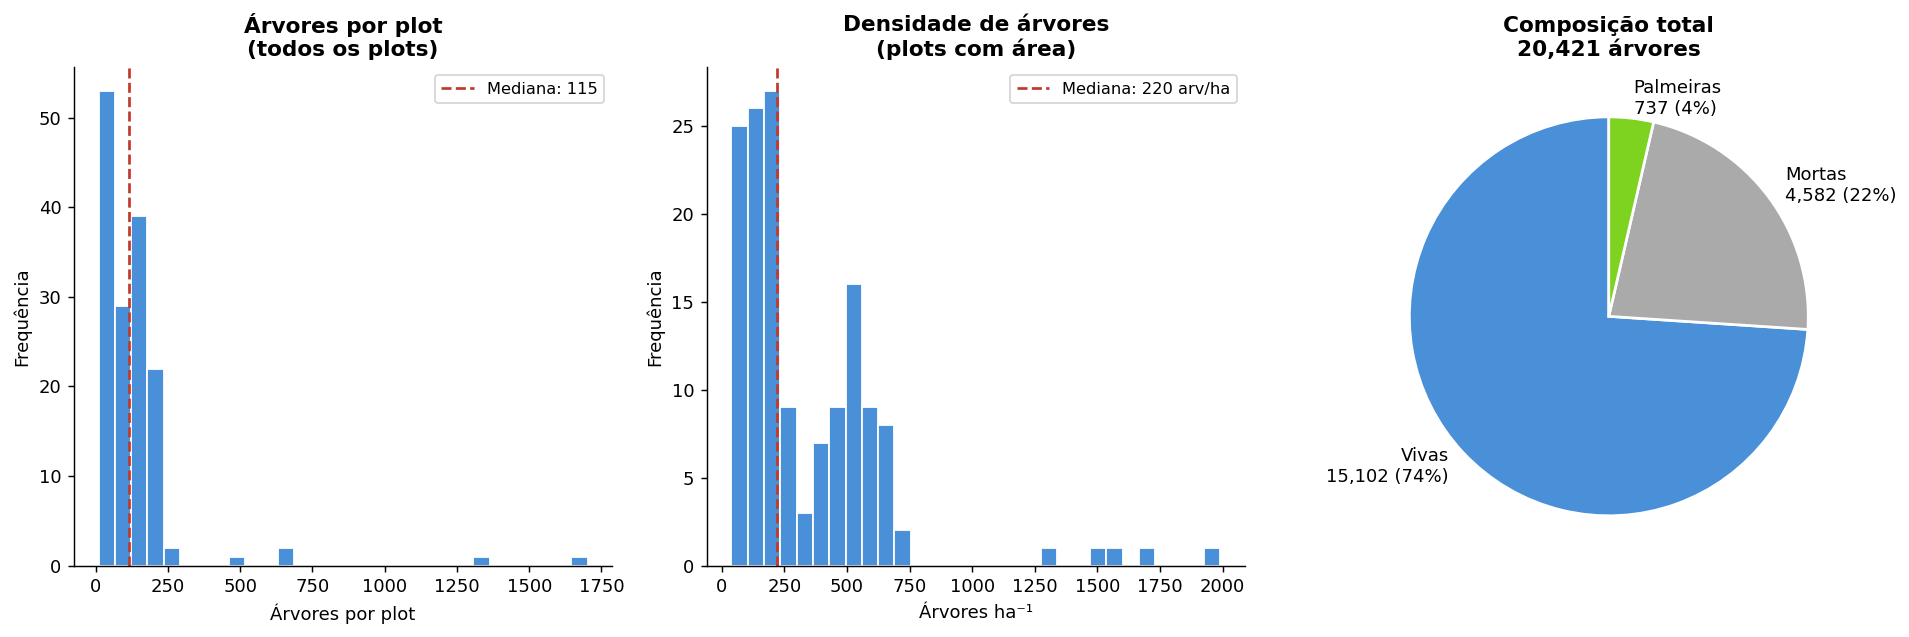

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma: n_arvores por plot
axes[0].hist(df["n_arvores"], bins=30, color="#4a90d9", edgecolor="white")
axes[0].axvline(df["n_arvores"].median(), color="#c0392b", linestyle="--",
                label=f"Mediana: {df['n_arvores'].median():.0f}")
axes[0].set_xlabel("Árvores por plot")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Árvores por plot\n(todos os plots)", fontweight="bold")
axes[0].legend(fontsize=9)

# Histograma: árvores/ha
axes[1].hist(dv["arvores_ha"], bins=30, color="#4a90d9", edgecolor="white")
axes[1].axvline(dv["arvores_ha"].median(), color="#c0392b", linestyle="--",
                label=f"Mediana: {dv['arvores_ha'].median():.0f} arv/ha")
axes[1].set_xlabel("Árvores ha⁻¹")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Densidade de árvores\n(plots com área)", fontweight="bold")
axes[1].legend(fontsize=9)

# Composição média por plot
comp = {
    "Vivas":     df["n_arvores_vivas"].sum(),
    "Mortas":    df["n_mortas"].sum(),
    "Palmeiras": df["n_palmeiras"].sum(),
}
total = sum(comp.values())
axes[2].pie(comp.values(), labels=[f"{k}\n{v:,} ({100*v/total:.0f}%)" for k,v in comp.items()],
            colors=["#4a90d9","#aaaaaa","#7ed321"], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[2].set_title(f"Composição total\n{total:,} árvores", fontweight="bold")

plt.tight_layout()
plt.show()

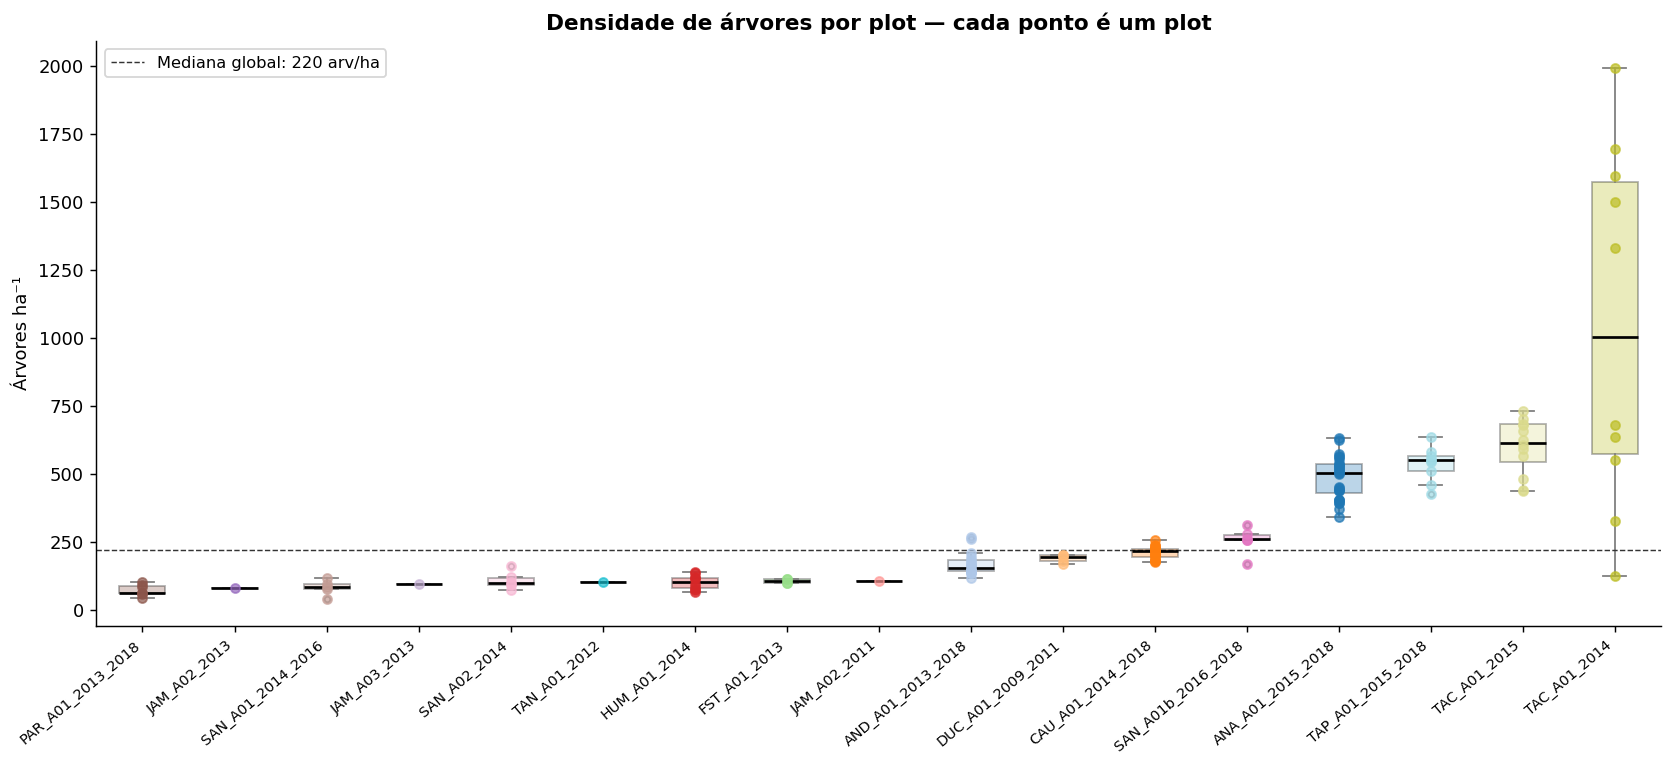

In [4]:
# Boxplot: árvores/ha por site (cada ponto = um plot)
order_arv = dv.groupby("site_short")["arvores_ha"].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
for i, site in enumerate(order_arv):
    vals = dv[dv["site_short"] == site]["arvores_ha"].values
    ax.scatter([i]*len(vals), vals, color=site_color[site], s=25, alpha=0.7, zorder=3)
    ax.boxplot(vals, positions=[i], vert=True, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=site_color[site], alpha=0.3),
               medianprops=dict(color="black", linewidth=1.5),
               whiskerprops=dict(color="gray"), capprops=dict(color="gray"),
               flierprops=dict(marker=".", alpha=0.4))

ax.set_xticks(range(len(order_arv)))
ax.set_xticklabels(order_arv, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Árvores ha⁻¹")
ax.set_title("Densidade de árvores por plot — cada ponto é um plot", fontweight="bold")
ax.axhline(dv["arvores_ha"].median(), color="#333", linestyle="--", linewidth=0.8,
           label=f"Mediana global: {dv['arvores_ha'].median():.0f} arv/ha")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Distribuição de biomassa por plot

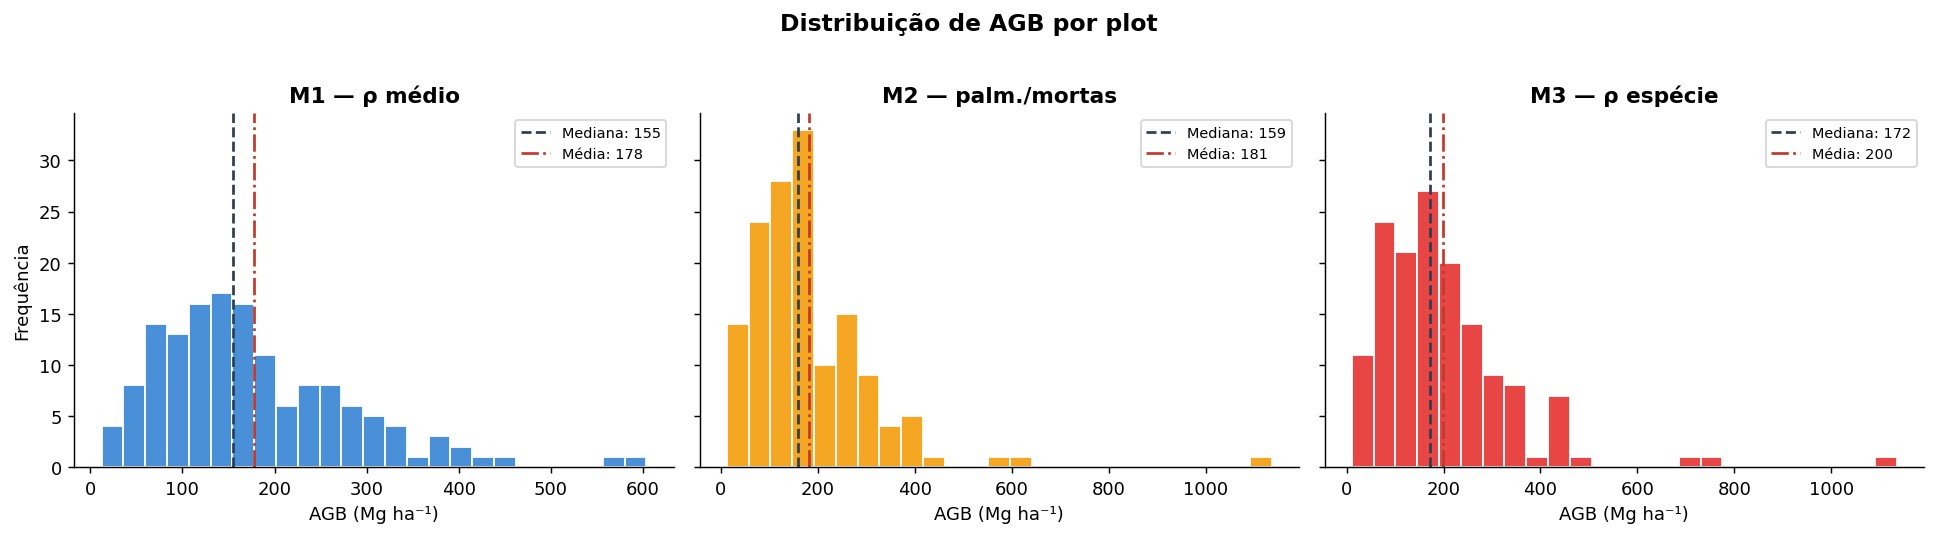

In [5]:
# Histogramas de AGB/ha por modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col, color, label in [
    (axes[0], "agb_m1_Mg_ha", C_M1, "M1 — ρ médio"),
    (axes[1], "agb_m2_Mg_ha", C_M2, "M2 — palm./mortas"),
    (axes[2], "agb_m3_Mg_ha", C_M3, "M3 — ρ espécie"),
]:
    vals = dv[col].dropna()
    ax.hist(vals, bins=25, color=color, edgecolor="white")
    ax.axvline(vals.median(), color="#2c3e50", linestyle="--",
               label=f"Mediana: {vals.median():.0f}")
    ax.axvline(vals.mean(), color="#c0392b", linestyle="-.",
               label=f"Média: {vals.mean():.0f}")
    ax.set_xlabel("AGB (Mg ha⁻¹)")
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequência")
plt.suptitle("Distribuição de AGB por plot", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

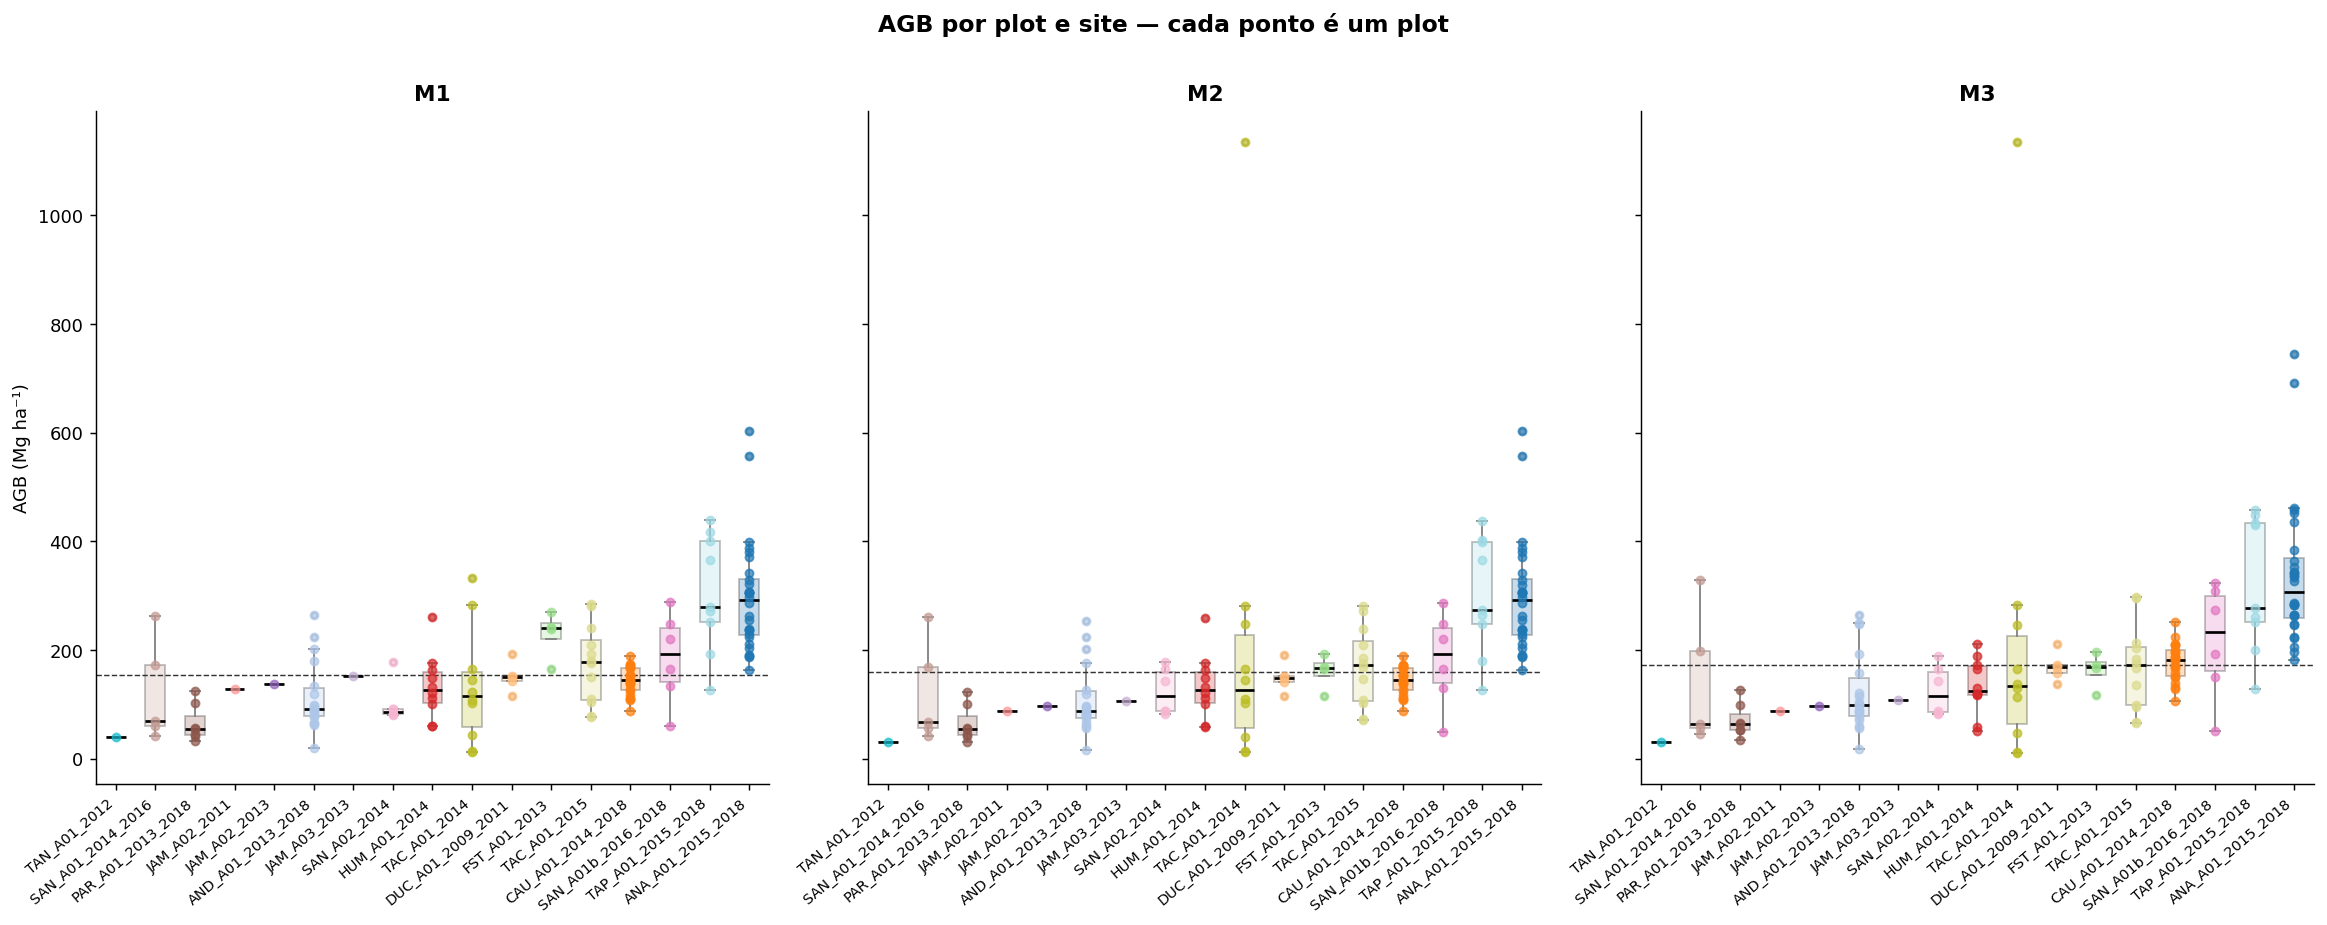

In [6]:
# Boxplot: AGB/ha por site, cada ponto = um plot
order_agb = dv.groupby("site_short")["agb_m3_Mg_ha"].median().sort_values().index

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, col, color, title in [
    (axes[0], "agb_m1_Mg_ha", C_M1, "M1"),
    (axes[1], "agb_m2_Mg_ha", C_M2, "M2"),
    (axes[2], "agb_m3_Mg_ha", C_M3, "M3"),
]:
    for i, site in enumerate(order_agb):
        vals = dv[dv["site_short"] == site][col].dropna().values
        if len(vals) == 0:
            continue
        ax.scatter([i]*len(vals), vals, color=site_color[site], s=20, alpha=0.7, zorder=3)
        ax.boxplot(vals, positions=[i], vert=True, widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor=site_color[site], alpha=0.25),
                   medianprops=dict(color="black", linewidth=1.5),
                   whiskerprops=dict(color="gray"), capprops=dict(color="gray"),
                   flierprops=dict(marker=".", alpha=0.3))
    ax.set_xticks(range(len(order_agb)))
    ax.set_xticklabels(order_agb, rotation=40, ha="right", fontsize=8)
    ax.set_title(title, fontweight="bold")
    ax.axhline(dv[col].median(), color="#333", linestyle="--", linewidth=0.8)

axes[0].set_ylabel("AGB (Mg ha⁻¹)")
plt.suptitle("AGB por plot e site — cada ponto é um plot", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Árvores/ha e Biomassa/ha por modelo

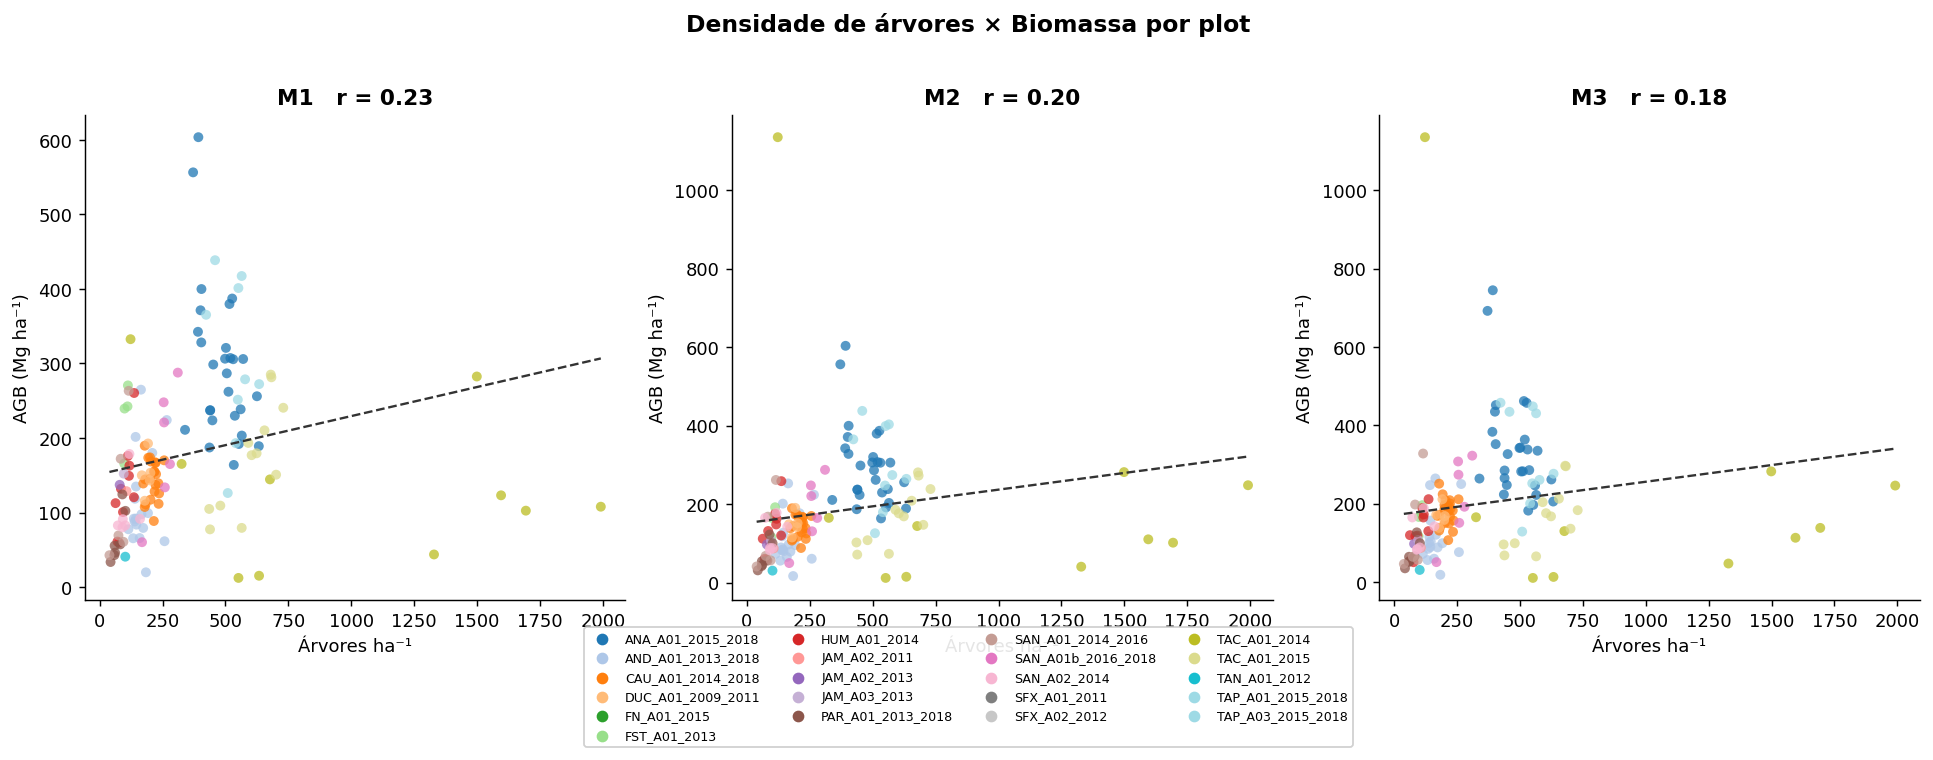

In [7]:
# Scatter: árvores/ha × AGB/ha por plot, colorido por site
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color, title in [
    (axes[0], "agb_m1_Mg_ha", C_M1, "M1"),
    (axes[1], "agb_m2_Mg_ha", C_M2, "M2"),
    (axes[2], "agb_m3_Mg_ha", C_M3, "M3"),
]:
    sv = dv[["site_short","arvores_ha",col]].dropna()
    for site in sites:
        sub = sv[sv["site_short"] == site]
        ax.scatter(sub["arvores_ha"], sub[col], color=site_color[site],
                   s=30, alpha=0.75, label=site, edgecolors="none")

    # Tendência global
    z = np.polyfit(sv["arvores_ha"], sv[col], 1)
    xr = np.linspace(sv["arvores_ha"].min(), sv["arvores_ha"].max(), 100)
    ax.plot(xr, np.polyval(z, xr), color="#333", linewidth=1.3, linestyle="--")

    r = sv[["arvores_ha", col]].corr().iloc[0, 1]
    ax.set_xlabel("Árvores ha⁻¹")
    ax.set_ylabel("AGB (Mg ha⁻¹)")
    ax.set_title(f"{title}   r = {r:.2f}", fontweight="bold")

# Legenda única
handles = [plt.scatter([],[], color=site_color[s], s=30, label=s) for s in sites]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=7,
           bbox_to_anchor=(0.5, -0.12), framealpha=0.9)
plt.suptitle("Densidade de árvores × Biomassa por plot", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Tabela resumo por plot (ordenada por AGB M3 decrescente)
tbl = dv[["site_short","plot_id","area_ha","n_arvores","arvores_ha",
          "n_arvores_vivas","n_mortas","n_palmeiras",
          "agb_m1_Mg_ha","agb_m2_Mg_ha","agb_m3_Mg_ha",
          "agc_m1_MgC_ha","agc_m2_MgC_ha","agc_m3_MgC_ha"]].copy()
tbl.columns = ["site","plot","area_ha","n_arv","arv_ha",
               "vivas","mortas","palms",
               "agb_M1","agb_M2","agb_M3","agc_M1","agc_M2","agc_M3"]
tbl = tbl.sort_values("agb_M3", ascending=False).reset_index(drop=True)
print(f"{'site':<35} {'plot':>6} {'area':>6} {'n_arv':>6} {'arv_ha':>7} "
      f"{'agb_M1':>8} {'agb_M2':>8} {'agb_M3':>8}  [Mg/ha]")
print("-" * 100)
for _, r in tbl.iterrows():
    print(f"{r.site:<35} {str(r.plot):>6} {r.area_ha:>6.2f} {r.n_arv:>6.0f} {r.arv_ha:>7.0f} "
          f"{r.agb_M1:>8.1f} {r.agb_M2:>8.1f} {r.agb_M3:>8.1f}")

site                                  plot   area  n_arv  arv_ha   agb_M1   agb_M2   agb_M3  [Mg/ha]
----------------------------------------------------------------------------------------------------
TAC_A01_2014                        <pandas.plotting.PlotAccessor object at 0x7010d458a990>   0.09     11     123    332.6   1135.2   1135.2
ANA_A01_2015_2018                   <pandas.plotting.PlotAccessor object at 0x7010d4f998e0>   0.26    102     392    603.7    603.7    744.7
ANA_A01_2015_2018                   <pandas.plotting.PlotAccessor object at 0x7010d4c70ad0>   0.28    103     371    556.5    556.5    692.1
ANA_A01_2015_2018                   <pandas.plotting.PlotAccessor object at 0x7010d458a690>   0.24    125     516    379.8    379.8    462.0
TAP_A01_2015_2018                   <pandas.plotting.PlotAccessor object at 0x7010d458a990>   0.25    105     423    365.3    365.3    457.7
ANA_A01_2015_2018                   <pandas.plotting.PlotAccessor object at 0x7010d4f998e0>  

In [9]:
# Resumo estatístico global
print("=" * 65)
print("RESUMO GLOBAL — nível de plot")
print("=" * 65)
print(f"  Plots total: {len(df)} · com área: {len(dv)}")
print(f"  Área total:  {dv.area_ha.sum():.1f} ha")
print(f"  Árvores:     {df.n_arvores.sum():,}")
print(f"               vivas {df.n_arvores_vivas.sum():,} · mortas {df.n_mortas.sum():,} · palmeiras {df.n_palmeiras.sum():,}")
print()
print(f"  {'Modelo':<8} {'média':>10} {'mediana':>10} {'p25':>8} {'p75':>8} {'min':>8} {'max':>8}  [Mg/ha]")
for m, col in [("M1","agb_m1_Mg_ha"),("M2","agb_m2_Mg_ha"),("M3","agb_m3_Mg_ha")]:
    v = dv[col].dropna()
    print(f"  {m:<8} {v.mean():>10.1f} {v.median():>10.1f} {v.quantile(.25):>8.1f} "
          f"{v.quantile(.75):>8.1f} {v.min():>8.1f} {v.max():>8.1f}")
print()
print(f"  {'Modelo':<8} {'média':>10} {'mediana':>10}  [MgC/ha]")
for m, col in [("M1","agc_m1_MgC_ha"),("M2","agc_m2_MgC_ha"),("M3","agc_m3_MgC_ha")]:
    v = dv[col].dropna()
    print(f"  {m:<8} {v.mean():>10.1f} {v.median():>10.1f}")

RESUMO GLOBAL — nível de plot
  Plots total: 150 · com área: 146
  Área total:  71.7 ha
  Árvores:     20,597
               vivas 15,102 · mortas 4,582 · palmeiras 737

  Modelo        média    mediana      p25      p75      min      max  [Mg/ha]
  M1            177.8      154.9    102.3    239.3     12.3    603.7
  M2            181.0      158.9    101.1    237.3     12.3   1135.2
  M3            199.8      172.4    107.4    251.9     10.8   1135.2

  Modelo        média    mediana  [MgC/ha]
  M1             88.9       77.5
  M2             90.5       79.5
  M3             99.9       86.2
